## Heatmap for Spring Mattress by Years

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df =pd.read_csv("review-vc_sales_by_collection.csv")

In [4]:
df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


In [5]:
df['year'] = df['yr_month'].astype(str).str[:4]

In [6]:
spring_df = df[
    (df['financial_category']=='Spring Mattresses') &
    (df['year'].isin(['2022','2023','2024']))
].copy()

In [7]:
spring_df = spring_df[spring_df['collection'] != '__TOTAL__']

In [8]:
spring_df = spring_df.dropna(subset=['written_avg_rating'])

In [9]:
spring_df

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,year
354,202201,Spring Mattresses,8in GT Bonnell,3.818182,3.0,11.0,0.272727,NaN,NaN,NaN,NaN,101801.20,462.0,2022
357,202201,Spring Mattresses,8in Comfort Hybrid,3.000000,1.0,2.0,0.500000,NaN,NaN,NaN,NaN,5008.40,24.0,2022
360,202201,Spring Mattresses,6in GT Bonnell - 2PC,4.285714,1.0,7.0,0.142857,NaN,NaN,NaN,NaN,95110.34,379.0,2022
361,202201,Spring Mattresses,6in GT Bonnell,3.629630,7.0,27.0,0.259259,NaN,NaN,NaN,NaN,177253.00,1677.0,2022
362,202201,Spring Mattresses,14in PPSM Hybrid,1.500000,2.0,2.0,1.000000,NaN,NaN,NaN,NaN,7813.86,20.0,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21278,202412,Spring Mattresses,10in Modern-Look Hybrid,2.333333,2.0,3.0,0.666667,2.333333,2.0,3.0,0.666667,100957.04,481.0,2024
21280,202412,Spring Mattresses,10in HBSM w WonderBox,2.200000,3.0,5.0,0.600000,2.200000,3.0,5.0,0.600000,92092.07,396.0,2024
21283,202412,Spring Mattresses,10in Euro Top Bonnell w WonderBox,5.000000,0.0,1.0,0.000000,5.000000,0.0,1.0,0.000000,63612.18,421.0,2024
21287,202412,Spring Mattresses,10in Comfort Hybrid,4.000000,1.0,3.0,0.333333,4.000000,1.0,3.0,0.333333,70216.00,392.0,2024


In [10]:
top_cols = (
    spring_df.groupby('collection')['sales_amount']
    .sum()
    .sort_values(ascending=False)
    .head(30)
    .index
)

In [11]:
top_cols

Index(['6in GT Bonnell', '8in GT Bonnell', '12in Gel GT Hybrid',
       '14in Gel GT Hybrid', '10in PPSM Hybrid', '12in PPSM Hybrid',
       '12in NEBT', '10in Gel GT Hybrid', '10in GT Bonnell',
       '6in GT Bonnell - 2PC', '6in BNSM w WonderBox', '12in HBSM w WonderBox',
       '12in PPSM w WonderBox', '14in PPSM Hybrid', '13in NEBT',
       '10in Comfort Hybrid', '12in GT Bonnell', '8in BNSM w WonderBox',
       '14in HBSM w WonderBox', '12in Cooling Adaptive Hybrid',
       '10in PPSM w WonderBox', '10in Tight Top Bonnell',
       '12in Comfort Hybrid', '10in HBSM w WonderBox',
       '10in Cooling Adaptive Hybrid', '10in BNSM w WonderBox',
       '12in BNSM w WonderBox', '8in Comfort Hybrid',
       '12in Modern-Look Hybrid', '10in Modern-Look Hybrid'],
      dtype='object', name='collection')

In [12]:
spring_cols = spring_df[spring_df['collection'].isin(top_cols)].copy()

In [13]:
spring_cols['rating_bin'] = spring_cols['written_avg_rating'].round(1)

In [14]:
rating_bins = np.round(np.arange(0.1,5.1,0.1),1)

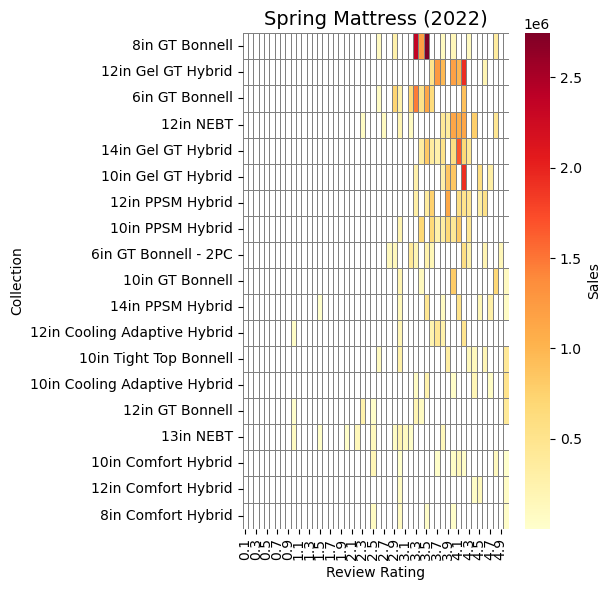

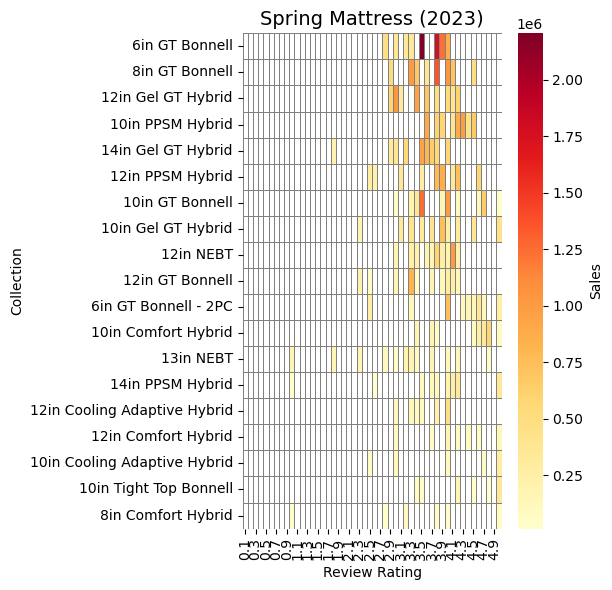

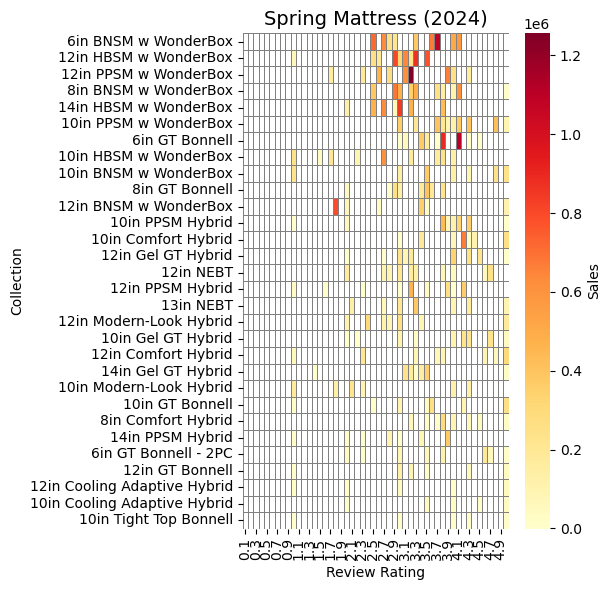

In [15]:
for year in ['2022','2023','2024']:
    pivot = (
        spring_cols[spring_cols['year']==year]
        .groupby(['collection','rating_bin'])['sales_amount']
        .sum()
        .unstack(fill_value=0)
       # .sort_index()
    )

    #누락 평점 구간을 포함시키고 정렬
    pivot = pivot.reindex(columns=rating_bins, fill_value=0)
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

    # 힌색으로 마스킹 하기
    mask = pivot == 0
    
    plt.figure(figsize=(6,6))
    sns.heatmap(pivot, cmap='YlOrRd', mask=mask, linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Sales'}, square=False)
                                                                                  
    plt.title(f'Spring Mattress ({year})', fontsize=14)
    plt.xlabel('Review Rating')
    plt.ylabel('Collection')
    plt.tight_layout()
    plt.show()
    